In [1]:
!pip install ipywidgets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 14.3 MB/s eta 0:00:00


In [2]:
import networkx as nx
import matplotlib.pyplot as plt
from collections import deque
import heapq
import ipywidgets as widgets
from IPython.display import display, clear_output

In [12]:
graph = {
    'A': ['B', 'C'],
    'B': ['A', 'D', 'E'],
    'C': ['A', 'F'],
    'D': ['B'],
    'E': ['B', 'F'],
    'F': ['C', 'E']
}

costs = {
    ('A', 'B'): 1, ('B', 'A'): 1,
    ('A', 'C'): 2, ('C', 'A'): 2,
    ('B', 'D'): 3, ('D', 'B'): 3,
    ('B', 'E'): 2, ('E', 'B'): 2,
    ('C', 'F'): 4, ('F', 'C'): 4,
    ('E', 'F'): 1, ('F', 'E'): 1
}

heuristic = {
    'A': 5, 'B': 4, 'C': 3,
    'D': 2, 'E': 1, 'F': 0
}


In [13]:
def draw_graph(path=None, visited=None):
    visited = visited or set()
    G = nx.Graph()
    pos = nx.spring_layout(graph, seed=42)

    for (u, v), cost in costs.items():
        G.add_edge(u, v, weight=cost)

    edge_labels = nx.get_edge_attributes(G, 'weight')
    node_labels = {node: f"{node}\n(h={heuristic[node]})" for node in G.nodes()}

    node_colors = ['lightgreen' if path and node in path
               else 'lightgray' if node in visited
               else 'skyblue' for node in G.nodes()]
    edge_colors = ['red' if path and (u in path and v in path and abs(path.index(u) - path.index(v)) == 1)
                   else 'black' for u, v in G.edges()]

    plt.figure(figsize=(8, 6))
    nx.draw(G, pos, with_labels=True, labels=node_labels,
            node_color=node_colors, edge_color=edge_colors,
            node_size=2000, font_size=10)
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=9)
    plt.title("Graph with Heuristic Values and Distances")
    plt.show()

In [14]:
def reconstruct_path(parent, node):
    path = []
    while node is not None:
        path.append(node)
        node = parent[node]
    return path[::-1]

In [15]:
def bfs(start, goal, graph):
    queue = deque([start])
    visited = set([start])
    parent = {start: None}

    while queue:
        node = queue.popleft()
        if node == goal:
            return reconstruct_path(parent, node), visited
        for neighbor in graph[node]:
            if neighbor not in visited:
                visited.add(neighbor)
                parent[neighbor] = node
                queue.append(neighbor)
    return None, visited

def dfs(start, goal, graph):
    stack = [start]
    visited = set([start])
    parent = {start: None}

    while stack:
        node = stack.pop()
        if node == goal:
            return reconstruct_path(parent, node), visited
        for neighbor in graph[node]:
            if neighbor not in visited:
                visited.add(neighbor)
                parent[neighbor] = node
                stack.append(neighbor)
    return None, visited

def ucs(start, goal, graph, costs):
    pq = [(0, start)]
    visited = set()
    parent = {start: None}
    cost_so_far = {start: 0}

    while pq:
        current_cost, node = heapq.heappop(pq)
        if node == goal:
            return reconstruct_path(parent, node), visited
        if node in visited:
            continue
        visited.add(node)
        for neighbor in graph[node]:
            new_cost = current_cost + costs.get((node, neighbor), 1)
            if neighbor not in cost_so_far or new_cost < cost_so_far[neighbor]:
                cost_so_far[neighbor] = new_cost
                parent[neighbor] = node
                heapq.heappush(pq, (new_cost, neighbor))
    return None, visited

def greedy(start, goal, graph, heuristic):
    pq = [(heuristic[start], start)]
    visited = set()
    parent = {start: None}

    while pq:
        _, node = heapq.heappop(pq)
        if node == goal:
            return reconstruct_path(parent, node), visited
        if node in visited:
            continue
        visited.add(node)
        for neighbor in graph[node]:
            if neighbor not in visited:
                parent[neighbor] = node
                heapq.heappush(pq, (heuristic[neighbor], neighbor))
    return None, visited

def astar(start, goal, graph, heuristic, costs):
    pq = [(heuristic[start], 0, start)]
    visited = set()
    parent = {start: None}
    g_cost = {start: 0}

    while pq:
        f, g, node = heapq.heappop(pq)
        if node == goal:
            return reconstruct_path(parent, node), visited
        if node in visited:
            continue
        visited.add(node)
        for neighbor in graph[node]:
            new_g = g + costs.get((node, neighbor), 1)
            if neighbor not in g_cost or new_g < g_cost[neighbor]:
                g_cost[neighbor] = new_g
                f = new_g + heuristic[neighbor]
                parent[neighbor] = node
                heapq.heappush(pq, (f, new_g, neighbor))
    return None, visited

In [16]:
def run_selected_algorithm(choice, start, goal):
    if choice == "bfs":
        path, visited = bfs(start, goal, graph)
    elif choice == "dfs":
        path, visited = dfs(start, goal, graph)
    elif choice == "ucs":
        path, visited = ucs(start, goal, graph, costs)
    elif choice == "greedy":
        path, visited = greedy(start, goal, graph, heuristic)
    elif choice == "astar":
        path, visited = astar(start, goal, graph, heuristic, costs)
    else:
        print("Invalid choice")
        return

    if path:
        # Calculate the total cost
        total_cost = sum(costs.get((path[i], path[i+1]), 0) for i in range(len(path)-1))

        print(f"Path found: {' -> '.join(path)}")
        print(f"Total Path Cost: {total_cost}")
        draw_graph(path, visited)
    else:
        print("No path found.")

def interactive_main():

    draw_graph()

    nodes = list(graph.keys())

    start_dropdown = widgets.Dropdown(options=nodes, value='A', description="Start:")
    goal_dropdown = widgets.Dropdown(options=nodes, value='F', description="Goal:")
    algo_dropdown = widgets.Dropdown(
        options=["bfs", "dfs", "ucs", "greedy", "astar"],
        value="bfs",
        description="Algorithm:"
    )

    run_button = widgets.Button(description="Run Search", button_style='success')
    output = widgets.Output()

    def on_run_clicked(b):
        with output:
            clear_output(wait=True)
            run_selected_algorithm(algo_dropdown.value, start_dropdown.value, goal_dropdown.value)

    run_button.on_click(on_run_clicked)

    display(widgets.HBox([start_dropdown, goal_dropdown, algo_dropdown]))
    display(run_button, output)



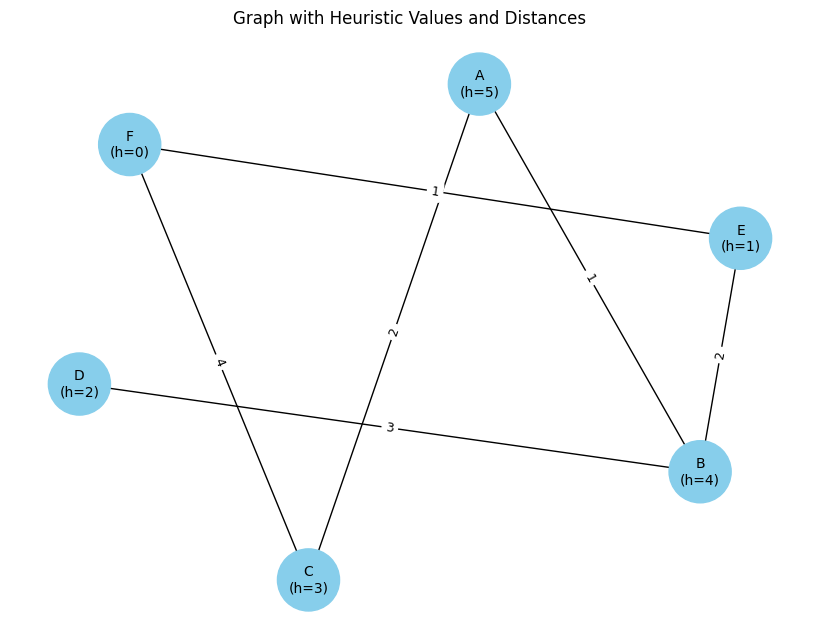

Button(button_style='success', description='Run Search', style=ButtonStyle())

Output()

In [17]:
interactive_main()